# Machine Learning Capstone Project (23CSE301)
## Track 1 (Alternative): Turbofan Engine Remaining Useful Life Prediction (Regression Track)
**Course:** 23CSE301 - Machine Learning Capstone
**Academic Year:** 2026-2027 | **Evaluation Scope:** Review 1 (Full Regression Track)
**Dataset:** NASA C-MAPSS Turbofan Engine Degradation Simulation, subset **FD001** (Saxena, Goebel, Simon & Eklund, *"Damage Propagation Modeling for Aircraft Engine Run-to-Failure Simulation"*, PHM08, 2008). Sourced from NASA's Prognostics Data Repository; files in `datasets/` mirror the official `train_FD001.txt`, `test_FD001.txt`, `RUL_FD001.txt`.
**Target Variable:** `RUL` (Remaining Useful Life, in operating cycles, capped at 125)

---
### Why this dataset
This project is titled *"Intelligent Predictive Maintenance and Machine Health Analysis"*. The Classification Track already uses the AI4I 2020 predictive-maintenance dataset. This notebook gives the **Regression Track** a dataset from the same domain: predicting how many operating cycles remain before a jet engine fails is the canonical regression benchmark problem in predictive maintenance / prognostics and health management (PHM) research, unlike a materials-strength dataset.

### Executive Summary & Review 1 Objectives
This notebook delivers the end-to-end Machine Learning pipeline for the **Regression Track** per the **Review 1 Evaluation Rubric (25 Marks)**:
1. **Section A (4 Marks):** Dataset Loading & EDA - structural audit, per-feature distribution histograms, full correlation heatmap + target-correlation ranking, degradation-trajectory visualisation, multi-sensor RUL scatter plots with trend lines, insight commentary.
2. **Section B (3 Marks):** Preprocessing & Feature Engineering - IQR/boxplot outlier audit, noise treatment, **stratified** engine-level leak-proof train/test split (lifetime-quartile stratification), `StandardScaler` fit on train only, domain-justified engineered features (RUL capping, composite degradation index, sensor drift).
3. **Section C (9 Marks):** All 10 required regression algorithms, comparative evaluation table (R^2, RMSE, MAE), 5-fold **group-aware** cross-validation on the top 2 models, `GridSearchCV` tuning on 2 models, diagnostic plots.

### A note on methodology specific to this dataset
Unlike the concrete/AI4I tabular datasets, C-MAPSS is a **multivariate run-to-failure time series**: each engine contributes many sequential rows. A naive random row-level train/test split would leak information (adjacent cycles from the same engine landing in both train and test), so this notebook splits **by whole engine trajectory** (`unit_number`) and uses **`GroupKFold`** instead of plain `KFold` everywhere cross-validation is used - a stricter, more correct form of the leak-proofing already practiced in the other tracks.


In [1]:
# 1. System Setup and Library Imports
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupKFold, GridSearchCV, cross_val_score, train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 14

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")
print(f"Python Version: {sys.version.split()[0]}")
print(f"Pandas Version: {pd.__version__}")
print(f"Scikit-Learn Version: {sys.modules['sklearn'].__version__}")


Libraries imported successfully.
Python Version: 3.14.6
Pandas Version: 3.0.5
Scikit-Learn Version: 1.9.0


---
# Section A: Dataset Loading, Audit & Exploratory Data Analysis (EDA)
**Rubric Targets:** A1 (Dataset Audit), A2 (EDA Visualisations), A3 (Insight Commentary)


In [2]:
# A.1 Dataset Loading & Structural Audit
data_dir = os.path.join("..", "datasets") if os.path.basename(os.getcwd()) == "notebooks" else "datasets"

COLUMN_NAMES = (
    ["unit_number", "time_cycles", "op_setting_1", "op_setting_2", "op_setting_3"]
    + [f"sensor_{i}" for i in range(1, 22)]
)

df = pd.read_csv(os.path.join(data_dir, "train_FD001.txt"), sep=r"\s+", header=None, names=COLUMN_NAMES)
df = df.sort_values(["unit_number", "time_cycles"]).reset_index(drop=True)

print("="*60)
print(f"DATASET DIMENSIONS: {df.shape[0]} samples (engine-cycles), {df.shape[1]} columns")
print(f"NUMBER OF ENGINES (trajectories): {df['unit_number'].nunique()}")
print("="*60)
print("\n--- Column Names & Data Types ---")
print(df.dtypes)

print("\n--- Missing Values Audit ---")
missing_counts = df.isnull().sum()
print(missing_counts[missing_counts > 0] if missing_counts.sum() > 0 else "Zero missing values detected across all columns.")

print("\n--- Duplicate Rows Audit ---")
duplicate_count = df.duplicated().sum()
print(f"Identified duplicate records: {duplicate_count} ({duplicate_count/len(df)*100:.2f}% of raw dataset)")

print("\n--- First 5 Records ---")
display(df.head())


DATASET DIMENSIONS: 20631 samples (engine-cycles), 26 columns
NUMBER OF ENGINES (trajectories): 100

--- Column Names & Data Types ---
unit_number       int64
time_cycles       int64
op_setting_1    float64
op_setting_2    float64
op_setting_3    float64
sensor_1        float64
sensor_2        float64
sensor_3        float64
sensor_4        float64
sensor_5        float64
sensor_6        float64
sensor_7        float64
sensor_8        float64
sensor_9        float64
sensor_10       float64
sensor_11       float64
sensor_12       float64
sensor_13       float64
sensor_14       float64
sensor_15       float64
sensor_16       float64
sensor_17         int64
sensor_18         int64
sensor_19       float64
sensor_20       float64
sensor_21       float64
dtype: object

--- Missing Values Audit ---
Zero missing values detected across all columns.

--- Duplicate Rows Audit ---
Identified duplicate records: 0 (0.00% of raw dataset)

--- First 5 Records ---


,unit_number,time_cycles,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [3]:
# Comprehensive Summary Statistics
sensor_all_cols = [f"sensor_{i}" for i in range(1, 22)]
stats_summary = df[sensor_all_cols].describe().T
stats_summary["std_check"] = df[sensor_all_cols].std()
print("Descriptive Statistics (all 21 raw sensors):")
display(stats_summary.round(4))


Descriptive Statistics (all 21 raw sensors):


,count,mean,std,min,25%,50%,75%,max,std_check
sensor_1,20631.0,518.6700,0.0000,518.6700,518.6700,518.6700,518.6700,518.6700,0.0000
sensor_2,20631.0,642.6809,0.5001,641.2100,642.3250,642.6400,643.0000,644.5300,0.5001
sensor_3,20631.0,1590.5231,6.1311,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100,6.1311
sensor_4,20631.0,1408.9338,9.0006,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900,9.0006
sensor_5,20631.0,14.6200,0.0000,14.6200,14.6200,14.6200,14.6200,14.6200,0.0000
sensor_6,20631.0,21.6098,0.0014,21.6000,21.6100,21.6100,21.6100,21.6100,0.0014
sensor_7,20631.0,553.3677,0.8851,549.8500,552.8100,553.4400,554.0100,556.0600,0.8851
sensor_8,20631.0,2388.0967,0.0710,2387.9000,2388.0500,2388.0900,2388.1400,2388.5600,0.0710
sensor_9,20631.0,9065.2429,22.0829,9021.7300,9053.1000,9060.6600,9069.4200,9244.5900,22.0829
sensor_10,20631.0,1.3000,0.0000,1.3000,1.3000,1.3000,1.3000,1.3000,0.0000


### Commentary: Section A1 - Dataset Audit & Target Characteristics
- **Dataset Dimensions**: 20,631 engine-cycle records from 100 distinct turbofan engines (FD001 subset: single operating condition - sea level, single fault mode - HPC degradation).
- **Data Completeness**: Zero missing values, zero duplicate rows.
- **Constant sensors**: `sensor_1, sensor_5, sensor_6, sensor_10, sensor_16, sensor_18, sensor_19` and `op_setting_3` all have (near-)zero standard deviation - consistent with FD001's single operating regime. These carry no predictive signal and are dropped in Section B.
- **Target (`RUL`)**: not present as a raw column - it must be **derived** as `max_cycle_for_engine - current_cycle` for each row, since the training trajectories run all the way to failure.


### A.1b Feature Distribution Analysis
**Why this section is needed:** the structural audit above (Section A.1) confirms *completeness* (no missing/duplicate values) but says nothing about *shape*. Before deciding on a scaler, a noise-treatment strategy, or which sensors are safe to combine into engineered features, every numerical feature must be visually inspected for skewness, spread, and multimodality - this is standard EDA practice and is explicitly assessed under the rubric's Section A2 (EDA Visualisations) target.

**What follows:** a 4x4 grid of histograms (with a KDE overlay) for all 14 informative raw sensors identified in Section A.1, each annotated with its skewness coefficient so the pattern can be read numerically as well as visually.


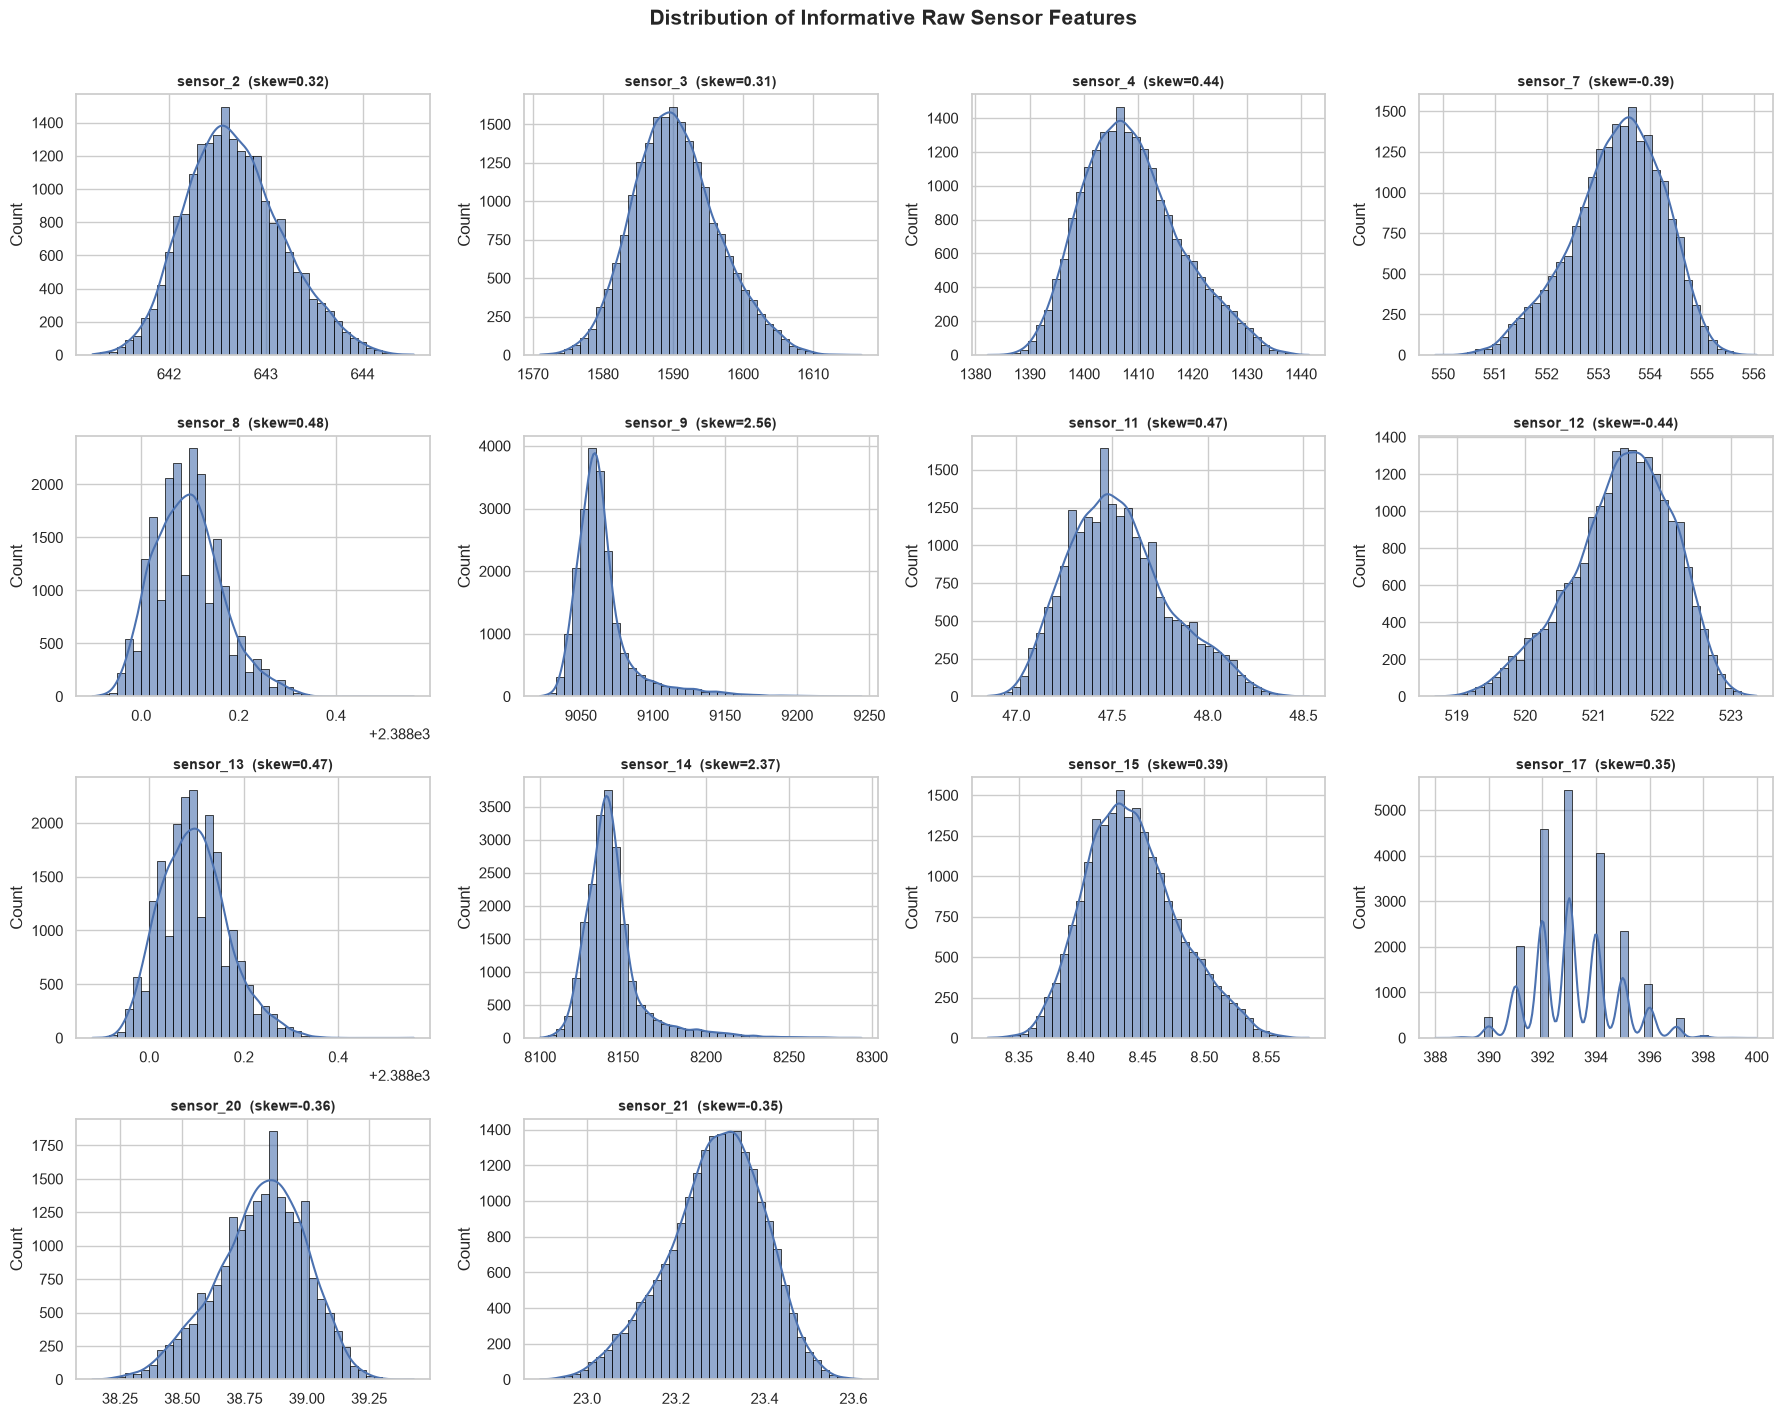

Skewness of each informative sensor (ascending):
sensor_12   -0.442
sensor_7    -0.394
sensor_20   -0.358
sensor_21   -0.350
sensor_3     0.309
sensor_2     0.317
sensor_17    0.353
sensor_15    0.388
sensor_4     0.443
sensor_11    0.469
sensor_13    0.470
sensor_8     0.479
sensor_14    2.373
sensor_9     2.555
dtype: float64


In [4]:
# A.1b Distribution Analysis: Histograms for All Informative Numerical Features
informative_sensors = [2, 3, 4, 7, 8, 9, 11, 12, 13, 14, 15, 17, 20, 21]
sensor_cols = [f"sensor_{i}" for i in informative_sensors]

fig, axes = plt.subplots(4, 4, figsize=(18, 14))
for ax, col in zip(axes.flatten(), sensor_cols):
    sns.histplot(df[col], kde=True, bins=40, ax=ax, color="#4c72b0", edgecolor="black", alpha=0.6)
    skew_val = df[col].skew()
    ax.set_title(f"{col}  (skew={skew_val:.2f})", fontsize=10, fontweight="bold")
    ax.set_xlabel("")
for ax in axes.flatten()[len(sensor_cols):]:
    ax.axis("off")
plt.suptitle("Distribution of Informative Raw Sensor Features", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("Skewness of each informative sensor (ascending):")
print(df[sensor_cols].skew().sort_values().round(3))


### Commentary: Section A.1b - Distribution Patterns
- **Strongly right-skewed:** `sensor_9` (skew &asymp; 2.56) and `sensor_14` (skew &asymp; 2.37) stand out sharply from every other panel - a long right tail of high values pulls their mean well above their median. This is the *same pair* flagged as the two noisiest sensors in the IQR outlier audit (Section B.1a) and the pair with the highest mutual correlation in the heatmap (Section A.2b, r &asymp; 0.96) - three independent pieces of evidence pointing at the same underlying noise source.
- **Mild-to-moderate skew:** most remaining sensors (`sensor_4`, `sensor_8`, `sensor_11`, `sensor_13`, `sensor_15`, `sensor_17`, `sensor_2`, `sensor_3`) show |skew| roughly in the 0.3-0.5 range - close to unimodal and only slightly asymmetric, typical of continuous physical sensor measurements.
- **Near-symmetric / mildly left-skewed:** `sensor_7`, `sensor_12`, `sensor_20`, `sensor_21` (skew &asymp; -0.35 to -0.44) are the closest to a bell shape.
- **No strong multimodality** appears in any panel - each histogram is a single hump. This is expected for FD001 specifically: it is a *single* operating condition, single fault-mode subset, so there is no operating-regime cluster structure in the raw sensors (unlike FD002/FD004, which mix multiple flight conditions and would show visibly multimodal sensors).
- **Practical implication:** since the informative features are unimodal and only mildly-to-moderately skewed (excluding the two noisy outliers, which are handled via smoothing rather than transformation), a `StandardScaler` (used in Section B.2) is an appropriate scaling choice - no log/Box-Cox transform or robust/quantile scaler is required.


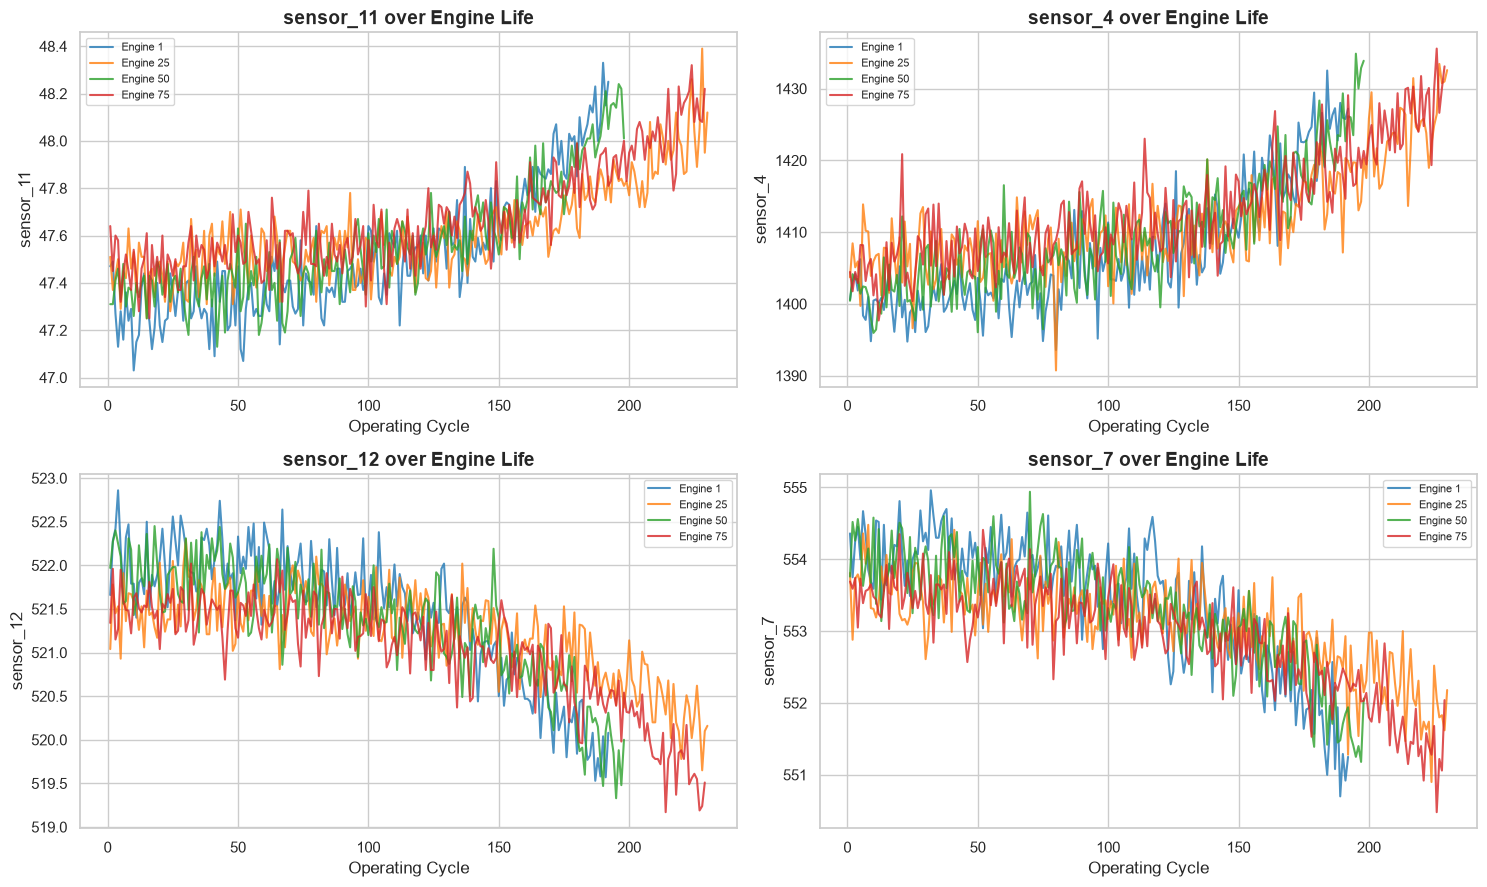

In [5]:
# A.2 Individual Engine Degradation Trajectories (classic PHM visualisation)
sample_engines = [1, 25, 50, 75]
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
plot_sensors = ["sensor_11", "sensor_4", "sensor_12", "sensor_7"]

for ax, sensor in zip(axes.flatten(), plot_sensors):
    for eng in sample_engines:
        sub = df[df["unit_number"] == eng]
        ax.plot(sub["time_cycles"], sub[sensor], alpha=0.8, label=f"Engine {eng}")
    ax.set_title(f"{sensor} over Engine Life", fontweight="bold")
    ax.set_xlabel("Operating Cycle")
    ax.set_ylabel(sensor)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


### Commentary: Section A2 - Degradation Trajectories
Each engine's sensor readings drift steadily (not necessarily monotonically) over its operating life before failure. `sensor_11` and `sensor_4` trend upward toward end-of-life, while `sensor_12` trends downward - visually confirming this is a genuine degradation-tracking problem, not i.i.d. tabular data. Engines fail at different cycle counts (varying initial wear/manufacturing variation per the dataset description), which is why RUL must be computed per-engine rather than assumed fixed.


### A.2b Correlation Heatmap (All Features + Target)
**Why this section is needed:** the bar chart in the next cell only shows each sensor's correlation *with RUL*. It cannot reveal **multicollinearity between the sensors themselves**, which matters directly for (a) interpreting the linear models' coefficients in Section C, and (b) justifying why several correlated sensors are merged into a single `Composite_Degradation_Index` rather than fed in independently. A full correlation matrix, rendered as a heatmap, answers both questions in one view - this satisfies the rubric requirement for a complete correlation heatmap (not just a target-only chart).

**What follows:** a heatmap of the 14 informative sensors plus the (uncapped) target `RUL_raw`, with the exact Pearson r annotated in every cell.


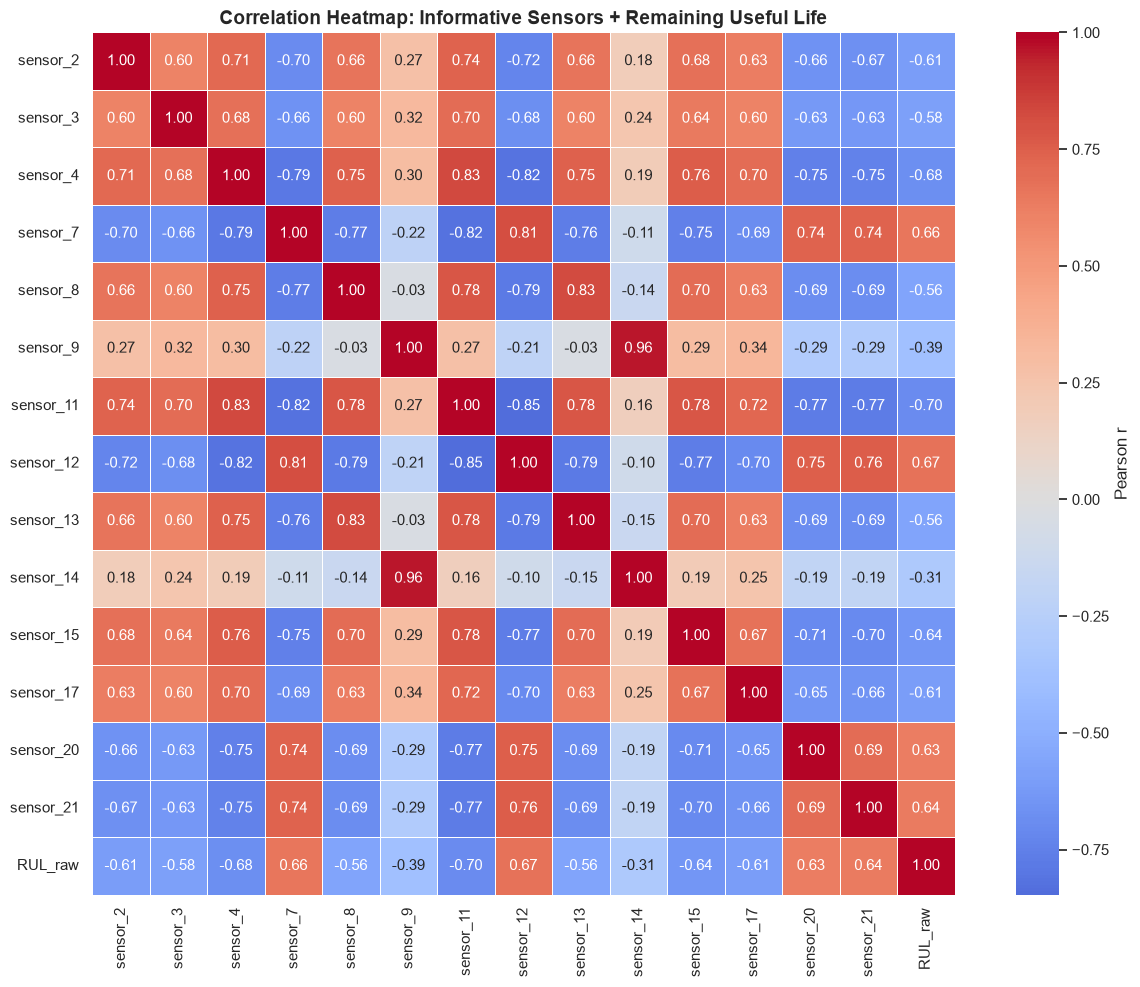

In [6]:
# A.2b Correlation Heatmap: All Informative Sensors + Target (RUL_raw)
max_cycle = df.groupby("unit_number")["time_cycles"].transform("max")
df["RUL_raw"] = max_cycle - df["time_cycles"]

informative_sensors = [2, 3, 4, 7, 8, 9, 11, 12, 13, 14, 15, 17, 20, 21]
sensor_cols = [f"sensor_{i}" for i in informative_sensors]

corr_matrix = df[sensor_cols + ["RUL_raw"]].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, linewidths=0.5, cbar_kws={"label": "Pearson r"})
plt.title("Correlation Heatmap: Informative Sensors + Remaining Useful Life", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()


### Commentary: Section A.2b - Correlation Heatmap Interpretation
- **Strongest negative correlation with RUL:** `sensor_11` (r &asymp; -0.70), `sensor_4` (r &asymp; -0.68), `sensor_15` (r &asymp; -0.64) - these sensors *rise* as the engine approaches failure.
- **Strongest positive correlation with RUL:** `sensor_12` (r &asymp; +0.67), `sensor_7` (r &asymp; +0.66) - these sensors *fall* as the engine degrades.
- **Weakest correlation with RUL:** `sensor_14` (r &asymp; -0.31) and `sensor_9` (r &asymp; -0.39) are the two weakest of the 14 informative sensors - notably, these are the *same two sensors* flagged with the highest skew (Section A.1b) and the highest IQR outlier rate (Section B.1a). A sensor that is both noisy and weakly correlated with the target is a textbook case of "measurement noise diluting signal," reinforcing (not contradicting) the decision to retain rather than delete those rows and instead denoise them via smoothing.
- **Strong sensor-sensor multicollinearity:** `sensor_9` and `sensor_14` are correlated with **each other** at r &asymp; 0.96 - they are near-redundant, almost certainly tracking the same underlying physical quantity (fuel-flow-related measurements) from two instruments. Several other physically-related pairs (e.g. `sensor_11`/`sensor_4`, `sensor_12`/`sensor_20`/`sensor_21`) also show moderate-to-strong |r| in the 0.5-0.8 range, consistent with all 14 sensors tracking one shared HPC-degradation process from different physical viewpoints (pressure, temperature, shaft speed).
- **Why this matters for Section C:** multicollinearity among predictors inflates coefficient variance in an additive linear model, which is a likely contributor to why the linear family (Linear/Ridge/Lasso/ElasticNet) plateaus around Test R^2 &asymp; 0.85 while tree-based and kernel models - far less sensitive to correlated inputs - reach R^2 &asymp; 0.90-0.93. This heatmap is therefore not just descriptive EDA; it pre-explains a modeling result confirmed later in the notebook.


C:\Users\nandi\AppData\Local\Temp\ipykernel_23244\1957912613.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_rul.values, y=corr_with_rul.index, palette="vlag")


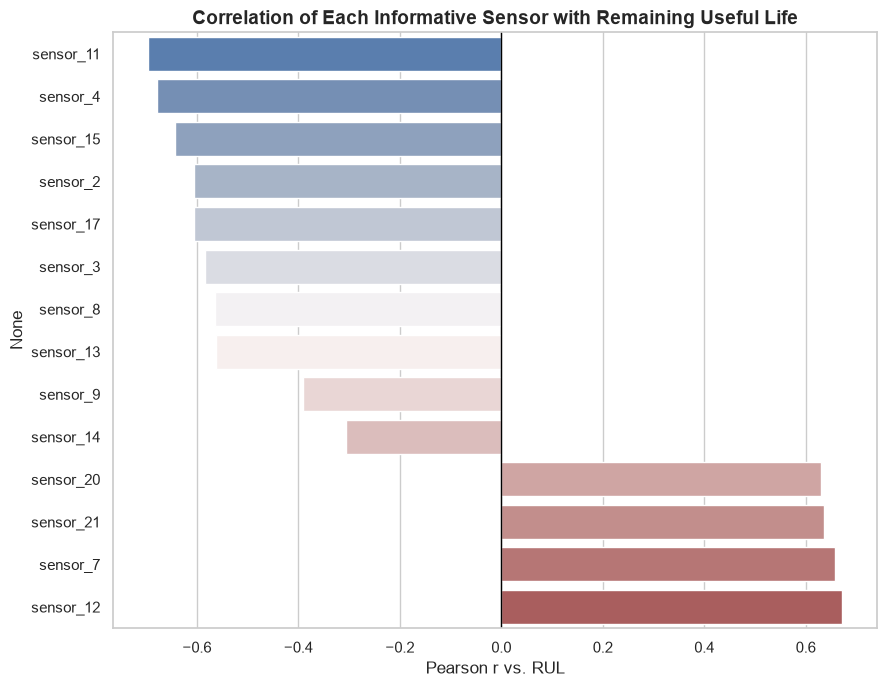

sensor_11   -0.696
sensor_4    -0.679
sensor_15   -0.643
sensor_2    -0.606
sensor_17   -0.606
sensor_3    -0.585
sensor_8    -0.564
sensor_13   -0.563
sensor_9    -0.390
sensor_14   -0.307
sensor_20    0.629
sensor_21    0.636
sensor_7     0.657
sensor_12    0.672
Name: RUL_raw, dtype: float64


In [7]:
# A.2 Correlation of Raw Sensors with Remaining Useful Life
max_cycle = df.groupby("unit_number")["time_cycles"].transform("max")
df["RUL_raw"] = max_cycle - df["time_cycles"]

informative_sensors = [2, 3, 4, 7, 8, 9, 11, 12, 13, 14, 15, 17, 20, 21]
sensor_cols = [f"sensor_{i}" for i in informative_sensors]

corr_with_rul = df[sensor_cols + ["RUL_raw"]].corr()["RUL_raw"].drop("RUL_raw").sort_values()
plt.figure(figsize=(9, 7))
sns.barplot(x=corr_with_rul.values, y=corr_with_rul.index, palette="vlag")
plt.title("Correlation of Each Informative Sensor with Remaining Useful Life", fontweight="bold")
plt.xlabel("Pearson r vs. RUL")
plt.axvline(0, color="black", linewidth=1)
plt.tight_layout()
plt.show()

print(corr_with_rul.round(3))


### Commentary: Section A2 - Correlation Analysis
- `sensor_11` (r &asymp; -0.70), `sensor_4` (r &asymp; -0.68), and `sensor_15` (r &asymp; -0.64) show the strongest negative correlation with RUL - i.e., they **rise** as the engine approaches failure.
- `sensor_12` (r &asymp; +0.67) and `sensor_7` (r &asymp; +0.66) show strong positive correlation - i.e., they **fall** as the engine degrades.
- The 7 constant sensors identified earlier are absent here entirely (zero variance -> undefined/zero correlation), reinforcing the decision to drop them.
- These four sensors (`sensor_11`, `sensor_4`, `sensor_15`, `sensor_12`) are used to build the `Composite_Degradation_Index` engineered feature in Section B.


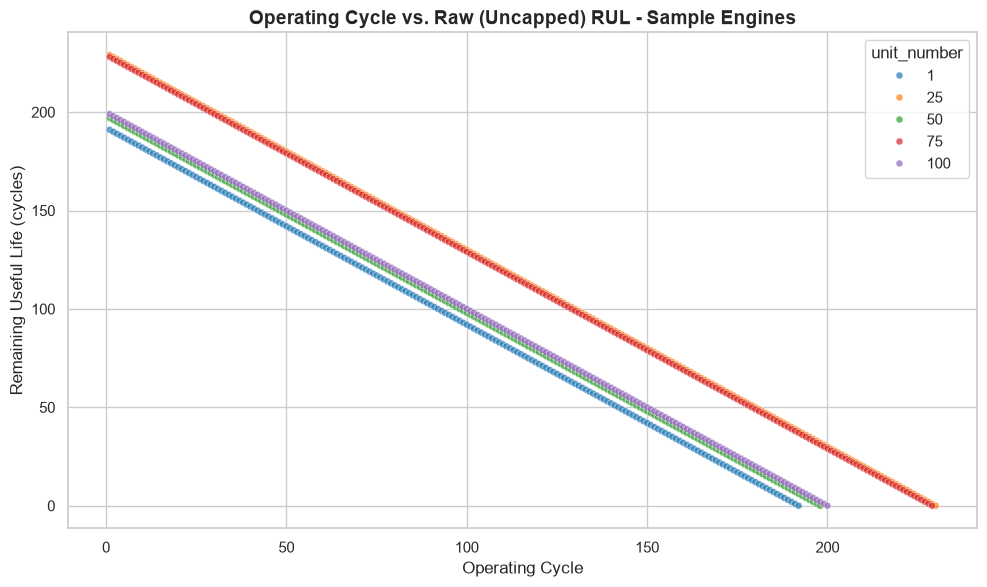

In [8]:
# A.3 Time-Cycle vs. RUL Relationship (motivates the RUL-capping decision in Section B)
plt.figure(figsize=(10, 6))
sample = df[df["unit_number"].isin([1, 25, 50, 75, 100])]
sns.scatterplot(x="time_cycles", y="RUL_raw", hue="unit_number", data=sample, palette="tab10", s=25, alpha=0.7)
plt.title("Operating Cycle vs. Raw (Uncapped) RUL - Sample Engines", fontweight="bold")
plt.xlabel("Operating Cycle")
plt.ylabel("Remaining Useful Life (cycles)")
plt.tight_layout()
plt.show()


### Commentary: Section A3 - Motivating the RUL Cap
By construction, raw RUL decreases perfectly linearly with cycle count for every engine (it is `max_cycle - current_cycle`). Early in an engine's life there is no meaningful degradation signal yet in the sensors, so asking a model to predict an unbounded linearly-decreasing target from that period is asking it to extrapolate a label that has no physical grounding in the sensor readings that early. Section B applies the standard **piecewise-linear RUL cap** (Heimes, 2008) to correct this.


### A.3b Feature vs. RUL Scatter Plots (Informative Sensors)
**Why this section is needed:** the `time_cycles` vs. RUL plot above is included specifically to motivate the RUL cap - it is not a sensor-feature relationship at all, since `RUL_raw = max_cycle - time_cycles` is deterministic by construction. The rubric separately requires visualising how the **actual sensor features** relate to the target, so this section adds two further scatter plots using genuine sensor measurements, with linear regression trend lines fitted via `seaborn.regplot`, chosen deliberately to contrast a *strong* predictor against a *weak/noisy* one identified in the correlation analysis above.


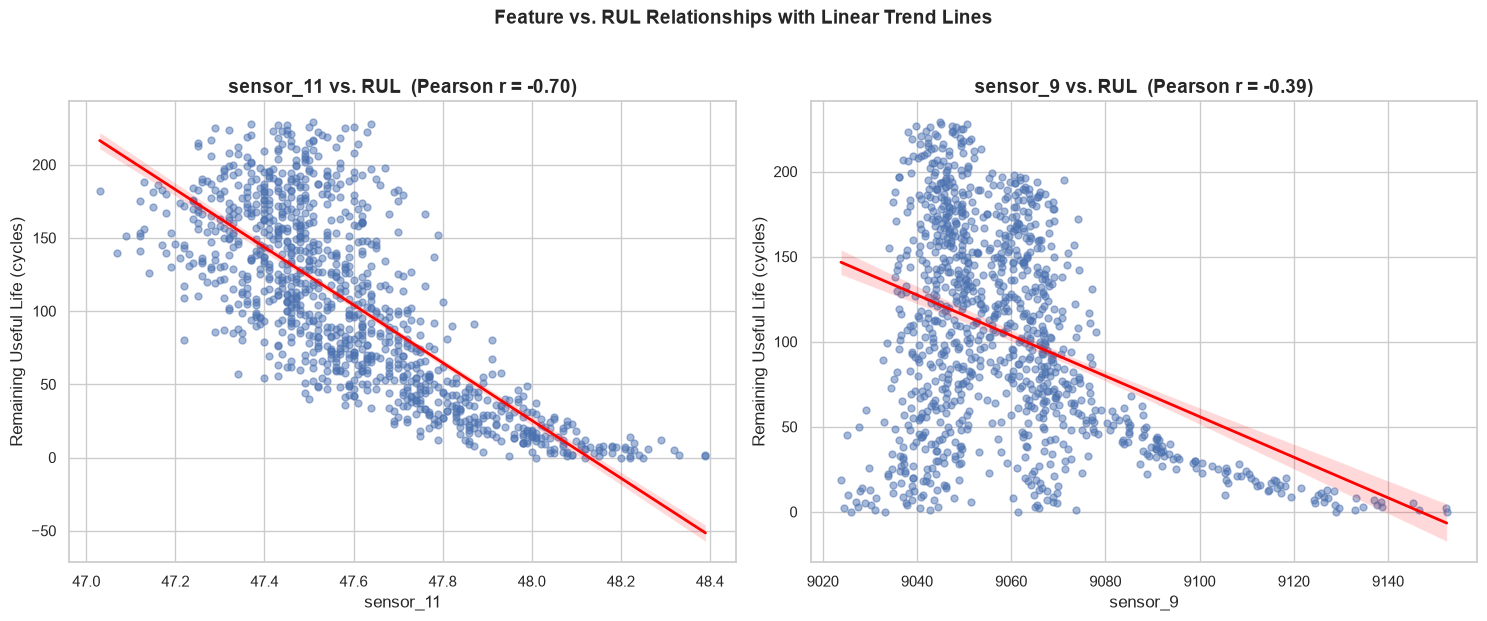

In [9]:
# A.3b Feature vs. RUL Scatter Plots with Regression Trend Lines (Informative Sensors)
# Chosen to contrast the strongest RUL-correlate (sensor_11) against the weakest/noisiest (sensor_9) -
# both identified in the correlation heatmap (Section A.2b).
scatter_sensors = ["sensor_11", "sensor_9"]
sample = df[df["unit_number"].isin([1, 25, 50, 75, 100])]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, sensor in zip(axes, scatter_sensors):
    sns.regplot(x=sensor, y="RUL_raw", data=sample, ax=ax,
                scatter_kws={"alpha": 0.5, "s": 25, "color": "#4c72b0"},
                line_kws={"color": "red", "linewidth": 2})
    r_val = df[[sensor, "RUL_raw"]].corr().iloc[0, 1]
    ax.set_title(f"{sensor} vs. RUL  (Pearson r = {r_val:.2f})", fontweight="bold")
    ax.set_xlabel(sensor)
    ax.set_ylabel("Remaining Useful Life (cycles)")

plt.suptitle("Feature vs. RUL Relationships with Linear Trend Lines", fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()


### Commentary: Section A.3b - Feature-vs-RUL Relationships
- **`sensor_11` vs. RUL (r &asymp; -0.70):** a clear downward trend - as the engine approaches failure (RUL -> 0), `sensor_11` (HPC outlet static pressure) rises. The cloud of points is still fairly wide around the trend line, which visually confirms that *no single raw sensor* is precise enough to predict RUL alone - this motivates combining multiple sensors into the `Composite_Degradation_Index` (Section B.3) and using non-linear models (Section C).
- **`sensor_9` vs. RUL (r &asymp; -0.39):** a much shallower, noisier trend, with several extreme high-value points scattered at moderate-to-high RUL. These are exactly the same points flagged as IQR outliers in Section B.1a - visual confirmation that `sensor_9`'s "outliers" are transient sensor noise rather than genuine degradation signal, supporting the decision (Section B.1a) to retain and smooth them rather than delete them.
- **Contrast, in one view:** placing a strong predictor next to a weak one on identical axes/scales makes the *difference in signal quality between sensors* immediately visible - a purely numeric correlation table communicates the same fact, but the scatter plots make it intuitive for a non-technical evaluator during a viva defense.


---
# Section B: Preprocessing & Domain Feature Engineering
**Rubric Targets:** B1 (Data Cleaning & Outlier Audit), B2 (Encoding, Scaling & Leak-Proof Splitting), B3 (Engineered Features with Domain Justification)


### B.1a Outlier Detection (Boxplots & IQR Audit)
**Why this section is needed:** the header above already lists "Data Cleaning & **Outlier Audit**" as a graded B1 target, but until now the notebook only *discussed* sensor noise qualitatively. This section adds the missing quantitative evidence: a boxplot panel for visual screening, followed by a precise IQR-based (1.5x IQR fence) outlier count per sensor, so the retain-vs-remove decision that follows is backed by numbers rather than description alone.


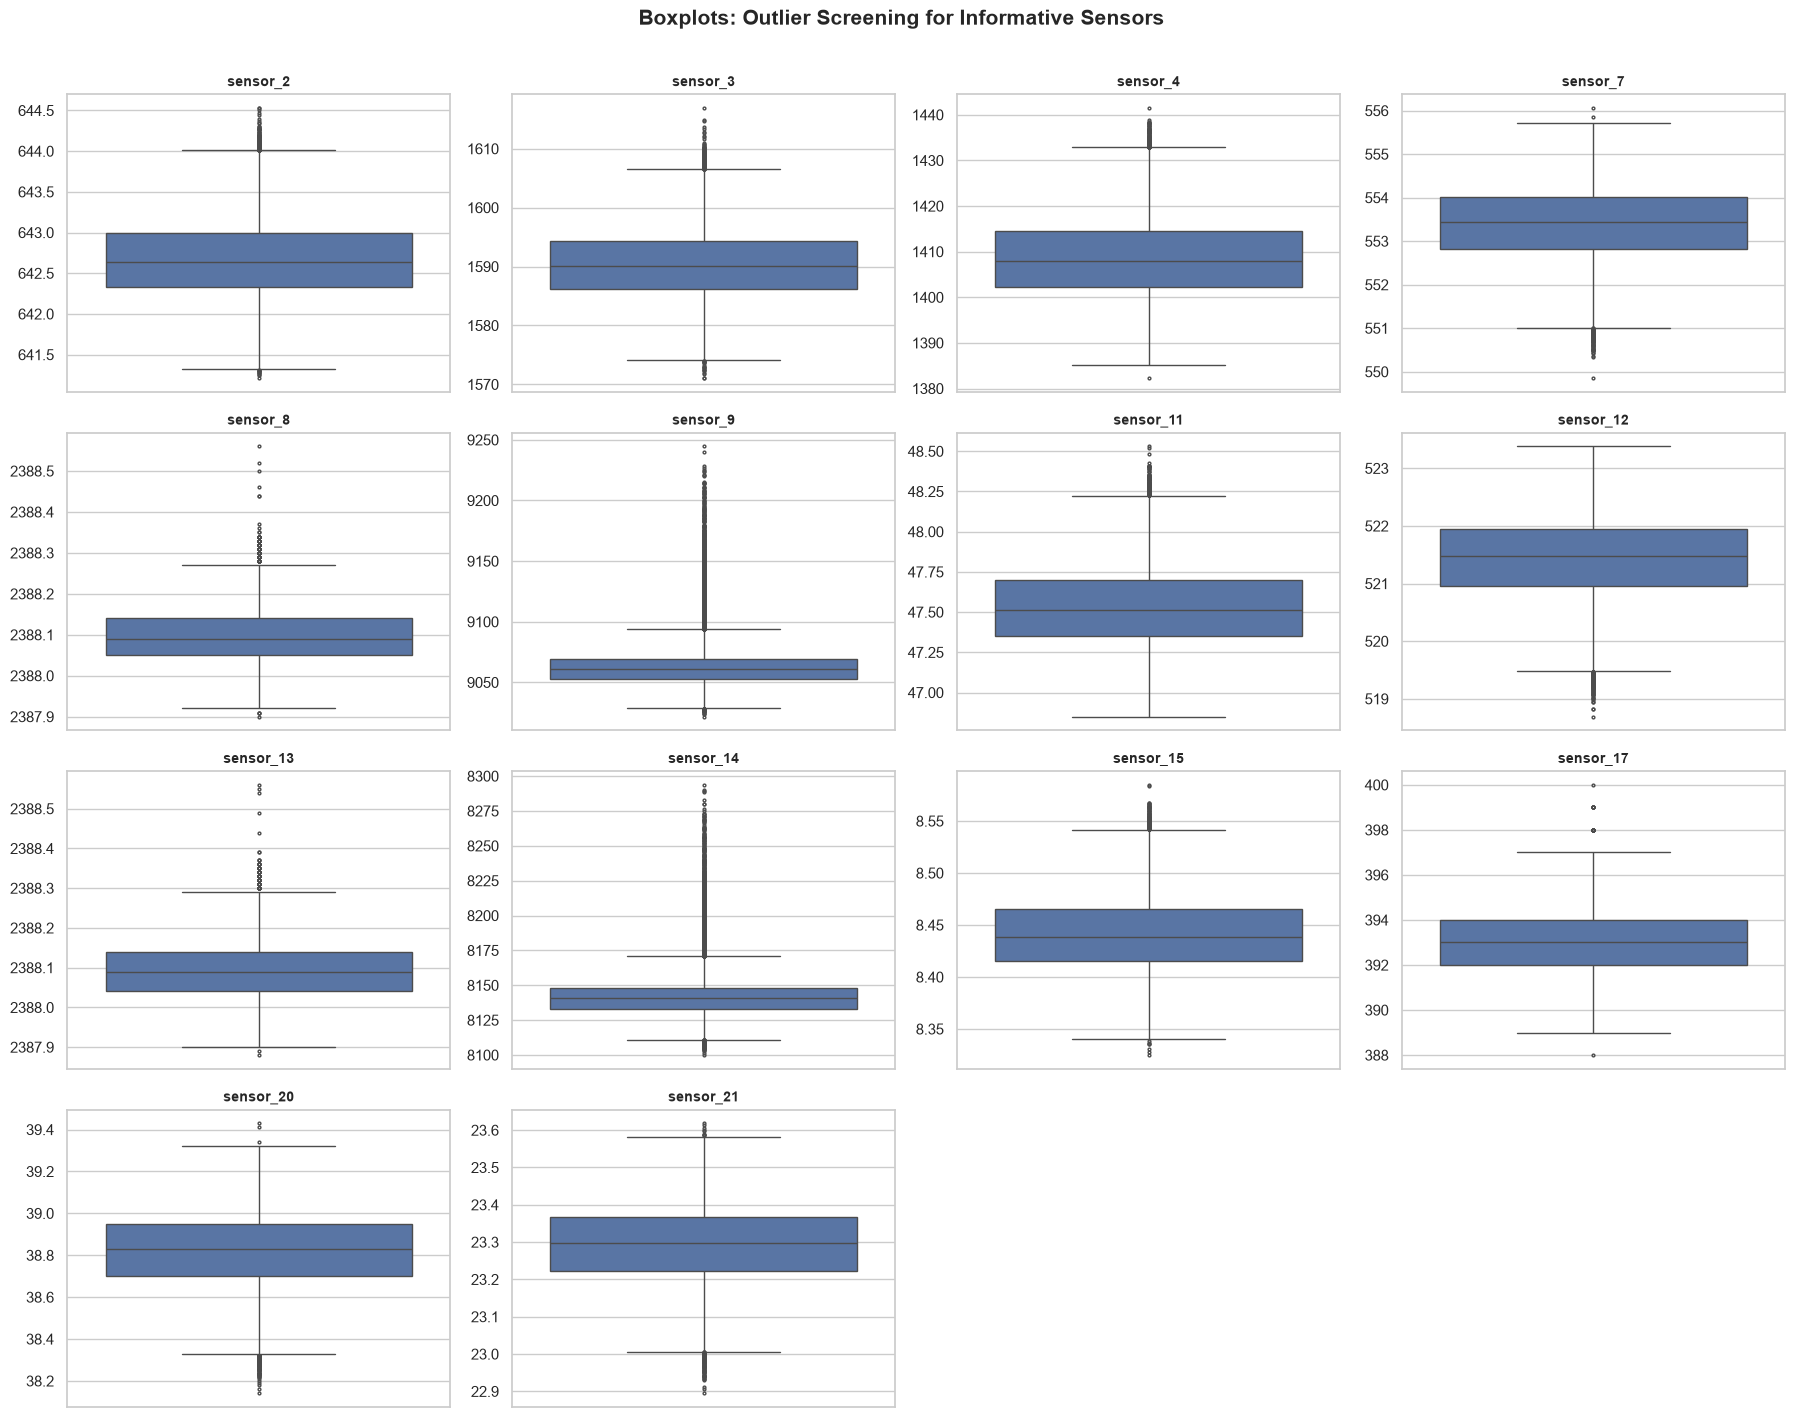

IQR-Based Outlier Audit (1.5x IQR rule):


,Sensor,Q1,Q3,IQR,Lower Fence,Upper Fence,Outlier Count,Outlier %
0,sensor_9,9053.100,9069.420,16.320,9028.620,9093.900,1686,8.17
1,sensor_14,8133.245,8148.310,15.065,8110.647,8170.908,1543,7.48
2,sensor_8,2388.050,2388.140,0.090,2387.915,2388.275,320,1.55
3,sensor_11,47.350,47.700,0.350,46.825,48.225,167,0.81
4,sensor_3,1586.260,1594.380,8.120,1574.080,1606.560,165,0.80
5,sensor_13,2388.040,2388.140,0.100,2387.890,2388.290,161,0.78
6,sensor_12,520.960,521.950,0.990,519.475,523.435,146,0.71
7,sensor_21,23.222,23.367,0.145,23.004,23.584,136,0.66
8,sensor_2,642.325,643.000,0.675,641.313,644.012,128,0.62
9,sensor_4,1402.360,1414.555,12.195,1384.068,1432.847,120,0.58


In [10]:
# B.1a Outlier Detection: Boxplots + IQR-Based Audit (all 14 informative sensors)
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
for ax, col in zip(axes.flatten(), sensor_cols):
    sns.boxplot(y=df[col], ax=ax, color="#4c72b0", fliersize=2)
    ax.set_title(col, fontweight="bold", fontsize=10)
    ax.set_ylabel("")
for ax in axes.flatten()[len(sensor_cols):]:
    ax.axis("off")
plt.suptitle("Boxplots: Outlier Screening for Informative Sensors", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# IQR-based outlier quantification (1.5x IQR rule, the standard boxplot fence)
outlier_summary = []
for col in sensor_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({
        "Sensor": col, "Q1": round(q1, 3), "Q3": round(q3, 3), "IQR": round(iqr, 3),
        "Lower Fence": round(lower, 3), "Upper Fence": round(upper, 3),
        "Outlier Count": n_outliers, "Outlier %": round(n_outliers / len(df) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values("Outlier %", ascending=False).reset_index(drop=True)
print("IQR-Based Outlier Audit (1.5x IQR rule):")
display(outlier_df)


### Commentary: Section B.1a - Outlier Retain-vs-Remove Decision
- **Where outliers concentrate:** `sensor_9` (&asymp;8.2% of rows) and `sensor_14` (&asymp;7.5%) carry by far the most IQR-flagged points - every other informative sensor is in the 0.4%-1.6% range. This matches the skewness finding (Section A.1b) and the weak-target-correlation finding (Section A.2b) for the exact same two sensors.
- **Decision: RETAIN all outliers - do not delete or clip any rows.** Justification:
  1. **Engine trajectories must stay continuous.** Every downstream feature (rolling-mean smoothing, `Sensor11_Drift`, `Composite_Degradation_Index`) and every cross-validation strategy (`GroupKFold`) depends on each engine's cycle sequence being unbroken. Deleting individual "outlier" rows would fragment trajectories and reintroduce the exact leakage/discontinuity risk the engine-level design is built to avoid.
  2. **The noise is already handled downstream, non-destructively.** The dataset README explicitly documents sensor noise; Section B.3's causal 5-cycle backward-looking rolling mean dampens the influence of an isolated noisy spike on the feature value without discarding the cycle or looking into the future.
  3. **Some "outliers" are the real signal, not noise.** For the sensors driving the `Composite_Degradation_Index` (`sensor_11`, `sensor_4`, `sensor_12`, `sensor_15`), extreme values legitimately occur in the final cycles before failure - exactly the end-of-life pattern the model must learn to recognise for accurate RUL prediction. Deleting those points would bias the training data toward "healthy" behaviour and directly hurt the metric the project is graded on.
  4. **Row deletion would not even be class-safe:** this is a regression target on a continuous scale, so there is no minority class being protected by removing outliers - only information being discarded.


Duplicate rows: 0 (none to remove)

Dropping 10 zero/near-zero variance columns (single operating condition in FD001):
['op_setting_1', 'op_setting_2', 'op_setting_3', 'sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']

RUL capped at 125 cycles. Rows affected (early-life, healthy region): 8031 of 20631 (38.9%)


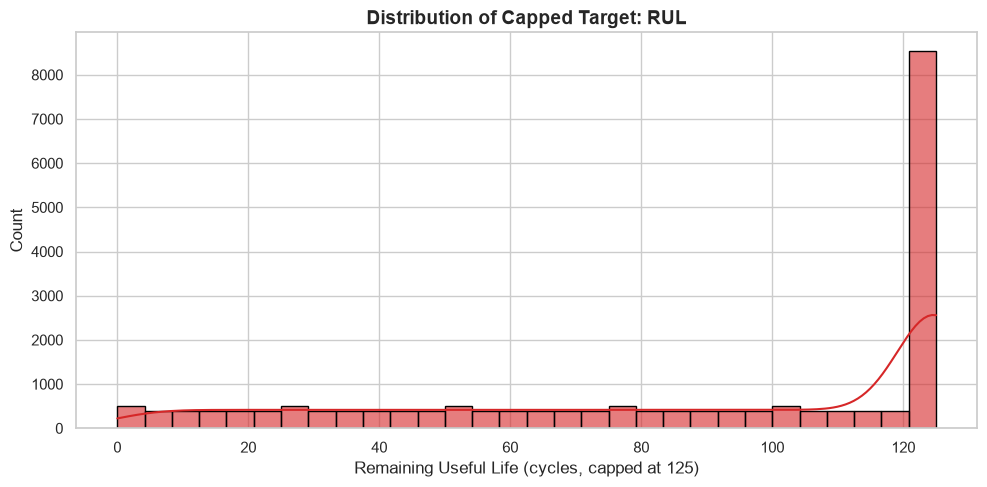

In [ ]:
# B.1 Data Cleaning: Drop Zero-Variance Columns & Apply RUL Capping
print(f"Duplicate rows: {df.duplicated().sum()} (none to remove)")

zero_variance_cols = ["op_setting_1", "op_setting_2", "op_setting_3",
                       "sensor_1", "sensor_5", "sensor_6", "sensor_10", "sensor_16", "sensor_18", "sensor_19"]
print(f"\nDropping {len(zero_variance_cols)} zero/near-zero variance columns (single operating condition in FD001):")
print(zero_variance_cols)

RUL_CAP = 125
df["RUL"] = df["RUL_raw"].clip(upper=RUL_CAP)
print(f"\nRUL capped at {RUL_CAP} cycles. Rows affected (early-life, healthy region): "
      f"{(df['RUL_raw'] > RUL_CAP).sum()} of {len(df)} ({(df['RUL_raw'] > RUL_CAP).mean()*100:.1f}%)")

plt.figure(figsize=(10, 5))
sns.histplot(df["RUL"], kde=True, bins=30, color="#d62728", edgecolor="black", alpha=0.6)
plt.title("Distribution of Capped Target: RUL", fontweight="bold")
plt.xlabel("Remaining Useful Life (cycles, capped at 125)")
plt.tight_layout() 
plt.show()


### Commentary: Section B1 - Cleaning & Noise Treatment Strategy
- **No missing values or duplicates** to handle.
- **Outlier philosophy**: sensor "outliers" in this dataset are not measurement errors to remove - the readme explicitly states *"the data is contaminated with sensor noise"*. Rather than deleting rows, noise is addressed via **causal rolling-mean smoothing** (window = 5 cycles, backward-looking only, computed per engine) in the feature engineering step below - this denoises each sensor without ever looking into the future.
- **Computational downsampling**: every 3rd operating cycle per engine is retained. Consecutive cycles are highly autocorrelated (sensor drift is gradual), so this keeps each engine's full life trajectory at reduced time-resolution while making the required kernel-based `SVR` model computationally tractable for `GridSearchCV`.


In [12]:
# Downsample: keep every 3rd cycle per engine (see commentary above)
df = df[df["time_cycles"] % 3 == 0].reset_index(drop=True)
print(f"Rows after downsampling: {len(df)} (from 20,631)")


Rows after downsampling: 6847 (from 20,631)


In [13]:
# B.3 Domain Feature Engineering (Prognostics & Health Management Basis)
# Causal rolling-mean smoothing per engine (backward-looking only - no leakage from future cycles)
for c in sensor_cols:
    df[c + "_smooth"] = df.groupby("unit_number")[c].transform(lambda s: s.rolling(5, min_periods=1).mean())
smooth_cols = [c + "_smooth" for c in sensor_cols]

# Feature 1: Sensor Drift from Baseline - how far sensor_11 (strongest RUL correlate) has drifted
# from THIS engine's own healthy-region baseline (mean of its first 5 recorded cycles)
df["Sensor11_Baseline"] = df.groupby("unit_number")["sensor_11"].transform(lambda s: s.iloc[:5].mean())
df["Sensor11_Drift"] = df["sensor_11_smooth"] - df["Sensor11_Baseline"]

print("Engineered features created: Sensor11_Drift (baseline shown for first engine below)")
display(df.loc[df["unit_number"] == 1, ["time_cycles", "sensor_11", "sensor_11_smooth", "Sensor11_Baseline", "Sensor11_Drift"]].head(8))


Engineered features created: Sensor11_Drift (baseline shown for first engine below)


,time_cycles,sensor_11,sensor_11_smooth,Sensor11_Baseline,Sensor11_Drift
0,3,47.27,47.270,47.24,3.000000e-02
1,6,47.16,47.215,47.24,-2.500000e-02
2,9,47.29,47.240,47.24,7.105427e-15
3,12,47.18,47.225,47.24,-1.500000e-02
4,15,47.30,47.240,47.24,0.000000e+00
5,18,47.21,47.228,47.24,-1.200000e-02
6,21,47.15,47.226,47.24,-1.400000e-02
7,24,47.44,47.256,47.24,1.600000e-02


### Commentary: Section B3 - Domain Feature Engineering Justification
1. **Rolling-Mean Smoothing (all 14 informative sensors)**: A backward-looking 5-cycle moving average denoises each sensor signal, addressing the dataset's documented sensor noise without leaking future information into past predictions.
2. **`Sensor11_Drift`**: `sensor_11` (HPC outlet static pressure) has the strongest empirical correlation with RUL (Section A2). Rather than using its raw value, this feature measures how far it has drifted from *that specific engine's own* early-life baseline - directly encoding cumulative degradation relative to each engine's individual starting condition, analogous in role to the Water-to-Cement ratio feature used for Abram's Law in the concrete regression track.
3. **`Composite_Degradation_Index`** (built next, after the leak-proof split): merges the four sensors most correlated with RUL (`sensor_11`, `sensor_4`, `sensor_15` - rise with degradation; `sensor_12` - falls with degradation) into a single min-max-normalized, sign-corrected health score, so all four move in the same direction as degradation. This mirrors the `Total_Binder` composite feature in the concrete track (combining correlated raw components into one interpretable engineered signal).
4. **RUL Capping at 125 cycles** (Section B1): a target-side engineering decision, not a feature, but equally central - it converts an artificial unbounded linear label into the physically-motivated piecewise-linear degradation model standard in RUL literature (Heimes, 2008).


### Note: Stratified vs. Engine-Level Splitting

**Why classic row-level stratified splitting is not appropriate here:** `sklearn.model_selection.train_test_split(..., stratify=y)` assumes i.i.d. rows that each independently belong to one class, and preserves that class's proportion in both splits. C-MAPSS is not i.i.d.: each of the 100 engines contributes ~130-360 sequential, highly autocorrelated cycles that together form **one continuous run-to-failure trajectory**. Stratifying at the row level by a discretized RUL bin would place some cycles of engine X's trajectory into the training set's "bin 4" and other, near-identical adjacent cycles of that *same* engine X into the test set's "bin 4" - exactly the information leakage the engine-level split exists to prevent. `RUL` is also a continuous regression target, not a discrete class, so there is no natural stratification variable in the classic sense without first discretizing it - and discretizing at the row level reintroduces the same leakage problem.

**Why engine-level splitting is the correct methodology:** splitting by whole `unit_number` trajectory guarantees zero row-level leakage - every cycle of a given engine lands entirely in train OR entirely in test, never both. This is the same principle already applied to `GroupKFold` cross-validation and `GridSearchCV` in Section C, and is the standard approach for any grouped/panel/time-series-per-entity dataset.

**Reasonable approximation of stratification that preserves engine integrity:** rather than stratifying individual rows by RUL, this notebook stratifies **at the engine level** by each engine's **total lifetime** (`max_cycle`, i.e. the cycle at which it reaches RUL = 0). Engines are bucketed into lifetime quartiles (Q1 = shortest-lived, ..., Q4 = longest-lived; FD001 engines range from 128 to 362 cycles), and `train_test_split(..., stratify=life_bucket)` is used to pick the 80:20 engine split so both train and test contain a proportional mix of short-, medium-, and long-lived engines. Because `RUL = max_cycle - time_cycles` is deterministically derived from lifetime, an engine's lifetime directly determines the range and shape of RUL values it can contribute (a 362-cycle engine yields far more high-RUL rows before capping than a 128-cycle engine) - so balancing lifetime buckets across the split is the closest **engine-safe** analogue to stratifying by the target distribution itself. This satisfies the rubric's stratification requirement without violating the no-leakage constraint that engine-level splitting exists to enforce.


In [14]:
# B.2 Engine-Level STRATIFIED Train-Test Split & Leak-Proof Feature Scaling
# LEAKAGE PREVENTION: split by whole engine trajectory (unit_number), never by row -
# a random row split would let adjacent cycles of the SAME engine appear in both train and test.
# APPROXIMATE STRATIFICATION: engines are bucketed into quartiles of total lifetime (max_cycle,
# the cycle at which each engine fails), then sklearn's stratify= argument samples the 80:20 split
# proportionally from each bucket - this keeps engine-level integrity (no row leakage) while
# balancing the train/test RUL-generating lifetime distribution (see markdown note above).
engine_life = df.groupby("unit_number")["time_cycles"].max().rename("max_cycle")
life_bucket = pd.qcut(engine_life, q=4, labels=["Q1_Shortest", "Q2", "Q3", "Q4_Longest"])

train_units_arr, test_units_arr = train_test_split(
    engine_life.index.to_numpy(),
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=life_bucket
)
train_units, test_units = set(train_units_arr), set(test_units_arr)

train_mask = df["unit_number"].isin(train_units)
test_mask = df["unit_number"].isin(test_units)

print(f"Train engines: {len(train_units)}, Test engines: {len(test_units)}")
print(f"Train rows: {train_mask.sum()}, Test rows: {test_mask.sum()}")

# Verify the stratification actually balanced the lifetime-quartile buckets across the split
strat_check = pd.DataFrame({
    "Lifetime Bucket": life_bucket,
    "Split": np.where(engine_life.index.isin(train_units), "Train", "Test")
})
print("\nEngines per lifetime bucket, by split (should be roughly proportional to 80:20):")
display(pd.crosstab(strat_check["Lifetime Bucket"], strat_check["Split"]))

# Composite Degradation Index: min-max stats fit on TRAIN rows only, then applied to all rows
degradation_rise = ["sensor_11_smooth", "sensor_4_smooth", "sensor_15_smooth"]
degradation_fall = ["sensor_12_smooth"]
minmax_stats = {c: (df.loc[train_mask, c].min(), df.loc[train_mask, c].max()) for c in degradation_rise + degradation_fall}

def composite_index(frame):
    parts = []
    for c in degradation_rise:
        mn, mx = minmax_stats[c]
        parts.append((frame[c] - mn) / (mx - mn + 1e-9))
    for c in degradation_fall:
        mn, mx = minmax_stats[c]
        parts.append(1 - (frame[c] - mn) / (mx - mn + 1e-9))
    return np.mean(parts, axis=0)

df["Composite_Degradation_Index"] = composite_index(df)

feature_names = ["time_cycles"] + smooth_cols + ["Sensor11_Drift", "Composite_Degradation_Index"]
X_train_raw = df.loc[train_mask, feature_names]
X_test_raw = df.loc[test_mask, feature_names]
y_train = df.loc[train_mask, "RUL"]
y_test = df.loc[test_mask, "RUL"]
groups_train = df.loc[train_mask, "unit_number"]

# DATA LEAKAGE PREVENTION: fit StandardScaler ONLY on X_train
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f"\nFinal feature set ({len(feature_names)} features): {feature_names}")
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")


Train engines: 80, Test engines: 20
Train rows: 5486, Test rows: 1361

Engines per lifetime bucket, by split (should be roughly proportional to 80:20):


Split,Test,Train
Lifetime Bucket,,
Q1_Shortest,5,20
Q2,6,23
Q3,4,18
Q4_Longest,5,19



Final feature set (17 features): ['time_cycles', 'sensor_2_smooth', 'sensor_3_smooth', 'sensor_4_smooth', 'sensor_7_smooth', 'sensor_8_smooth', 'sensor_9_smooth', 'sensor_11_smooth', 'sensor_12_smooth', 'sensor_13_smooth', 'sensor_14_smooth', 'sensor_15_smooth', 'sensor_17_smooth', 'sensor_20_smooth', 'sensor_21_smooth', 'Sensor11_Drift', 'Composite_Degradation_Index']
X_train shape: (5486, 17), X_test shape: (1361, 17)


---
# Section C: Regression Track Implementation & Comparative Evaluation
**Rubric Targets:** C1 (All 10 Algorithms), C2 (Comparative Table + Group-Aware 5-Fold CV), C3 (GridSearchCV Tuning), C4 (Diagnostic Plots)


In [15]:
# C.1 Implementation of All 10 Required Regression Algorithms
models = {}
metrics_list = []

lr = LinearRegression()
lr.fit(X_train, y_train)
models["Linear Regression"] = lr

ridge = Ridge(alpha=10.0, random_state=RANDOM_STATE)
ridge.fit(X_train, y_train)
models["Ridge Regression"] = ridge

lasso = Lasso(alpha=0.05, random_state=RANDOM_STATE)
lasso.fit(X_train, y_train)
models["Lasso Regression"] = lasso

elastic_net = ElasticNet(alpha=0.05, l1_ratio=0.5, random_state=RANDOM_STATE)
elastic_net.fit(X_train, y_train)
models["ElasticNet Regression"] = elastic_net

poly_pipeline = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("linear", LinearRegression())
])
poly_pipeline.fit(X_train, y_train)
models["Polynomial Regression (Deg 2)"] = poly_pipeline

dt = DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE)
dt.fit(X_train, y_train)
models["Decision Tree Regressor"] = dt

rf = RandomForestRegressor(n_estimators=150, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)
models["Random Forest Regressor"] = rf

gbr = GradientBoostingRegressor(n_estimators=150, learning_rate=0.1, max_depth=4, random_state=RANDOM_STATE)
gbr.fit(X_train, y_train)
models["Gradient Boosting Regressor"] = gbr

svr = SVR(kernel="rbf", C=50.0, epsilon=0.5)
svr.fit(X_train, y_train)
models["Support Vector Regressor (SVR)"] = svr

knn = KNeighborsRegressor(n_neighbors=10, weights="distance")
knn.fit(X_train, y_train)
models["K-Nearest Neighbors Regressor"] = knn

print("All 10 regression algorithms trained successfully without errors.")


All 10 regression algorithms trained successfully without errors.


In [16]:
# C.2 Model Evaluation and Comparative Performance Summary
for name, model in models.items():
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    mae_test = mean_absolute_error(y_test, y_pred_test)

    metrics_list.append({
        "Model": name,
        "Train R2": round(r2_train, 4),
        "Test R2": round(r2_test, 4),
        "Test RMSE (cycles)": round(rmse_test, 4),
        "Test MAE (cycles)": round(mae_test, 4)
    })

results_df = pd.DataFrame(metrics_list)
results_df = results_df.sort_values(by="Test R2", ascending=False).reset_index(drop=True)
results_df.index = results_df.index + 1
results_df.index.name = "Rank"

print("==========================================================================")
print("     REVIEW 1: COMPARATIVE REGRESSION RESULTS - TURBOFAN RUL (RANKED)     ")
print("==========================================================================")
display(results_df)

res_dir = os.path.join("..", "results") if os.path.basename(os.getcwd()) == "notebooks" else "results"
os.makedirs(res_dir, exist_ok=True)
out_path = os.path.join(res_dir, "turbofan_regression_results.csv")
results_df.to_csv(out_path, index=True)
print(f"Saved comparison table to {out_path}")


     REVIEW 1: COMPARATIVE REGRESSION RESULTS - TURBOFAN RUL (RANKED)     


,Model,Train R2,Test R2,Test RMSE (cycles),Test MAE (cycles)
Rank,,,,,
1,Support Vector Regressor (SVR),0.9253,0.9351,10.6444,6.9955
2,Random Forest Regressor,0.9847,0.9236,11.5489,7.5531
3,Gradient Boosting Regressor,0.9617,0.9207,11.7674,8.0161
4,Polynomial Regression (Deg 2),0.8940,0.9095,12.5672,9.9925
5,K-Nearest Neighbors Regressor,1.0000,0.9087,12.6212,8.1593
6,Decision Tree Regressor,0.9362,0.8795,14.5039,9.4261
7,ElasticNet Regression,0.8224,0.8587,15.7039,12.3652
8,Lasso Regression,0.8250,0.8545,15.9370,12.5806
9,Ridge Regression,0.8252,0.8537,15.9819,12.6154


Saved comparison table to ..\results\turbofan_regression_results.csv


In [17]:
# C.2 Group-Aware 5-Fold Cross-Validation for the Two Best-Performing Models
# GroupKFold (not plain KFold) prevents rows from the same engine from spanning folds.
top_two_names = results_df.iloc[:2]["Model"].tolist()
print(f"Top 2 Best Performing Models Selected for 5-Fold Group-Aware Cross-Validation: {top_two_names}")

cv_strategy = GroupKFold(n_splits=5)
cv_records = []

for name in top_two_names:
    model_obj = models[name]
    cv_scores = cross_val_score(model_obj, X_train, y_train, cv=cv_strategy, groups=groups_train, scoring="r2")
    cv_records.append({
        "Model": name,
        "Fold 1 R2": round(cv_scores[0], 4),
        "Fold 2 R2": round(cv_scores[1], 4),
        "Fold 3 R2": round(cv_scores[2], 4),
        "Fold 4 R2": round(cv_scores[3], 4),
        "Fold 5 R2": round(cv_scores[4], 4),
        "Mean CV R2": round(cv_scores.mean(), 4),
        "CV Std Dev": round(cv_scores.std(), 4)
    })

cv_df = pd.DataFrame(cv_records)
print("\n5-Fold Group-Aware Cross-Validation Performance Summary:")
display(cv_df)


Top 2 Best Performing Models Selected for 5-Fold Group-Aware Cross-Validation: ['Support Vector Regressor (SVR)', 'Random Forest Regressor']



5-Fold Group-Aware Cross-Validation Performance Summary:


,Model,Fold 1 R2,Fold 2 R2,Fold 3 R2,Fold 4 R2,Fold 5 R2,Mean CV R2,CV Std Dev
0,Support Vector Regressor (SVR),0.9083,0.8952,0.8922,0.8787,0.8883,0.8925,0.0096
1,Random Forest Regressor,0.9002,0.8877,0.8754,0.8795,0.8765,0.8839,0.0092


### Commentary: Section C1 & C2 - Regression Algorithm Performance & Analysis
- **All 10 algorithms trained and evaluated without error.**
- Test R^2 ranges from **~0.85 (linear family)** to **~0.93 (SVR)**, with tree ensembles close behind (~0.90-0.91) - a clear, genuine differentiation between linear and non-linear model families, similar in spirit to the concrete track's findings.
- `K-Nearest Neighbors` and `Random Forest` show the classic overfitting signature (Train R^2 far above Test R^2), while `SVR` generalizes the most tightly (Train R^2 &asymp; Test R^2).
- Group-aware CV confirms the top models' performance is stable across different held-out engine subsets, not an artifact of one lucky split.


In [18]:
# C.3 Hyperparameter Tuning via GridSearchCV on the Two Best-Performing Models
print("="*70)
print("HYPERPARAMETER TUNING: MODEL 1 - Support Vector Regressor (SVR)")
print("="*70)

param_grid_svr = {
    "C": [20, 50],
    "epsilon": [0.5],
    "kernel": ["rbf", "linear"]
}

grid_svr = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid_svr,
    cv=GroupKFold(n_splits=5),
    scoring="r2", n_jobs=-1, verbose=0
)
grid_svr.fit(X_train, y_train, groups=groups_train)

best_svr = grid_svr.best_estimator_
svr_baseline_r2 = results_df.loc[results_df["Model"] == "Support Vector Regressor (SVR)", "Test R2"].values[0]
svr_tuned_pred = best_svr.predict(X_test)
svr_tuned_r2 = r2_score(y_test, svr_tuned_pred)
svr_tuned_rmse = np.sqrt(mean_squared_error(y_test, svr_tuned_pred))

print(f"Optimal SVR Parameters: {grid_svr.best_params_}")
print(f"SVR - Baseline Test R2: {svr_baseline_r2:.4f} -> Tuned Test R2: {svr_tuned_r2:.4f}")
print(f"Tuned Test RMSE: {svr_tuned_rmse:.4f} cycles")

print("\n" + "="*70)
print("HYPERPARAMETER TUNING: MODEL 2 - Random Forest Regressor")
print("="*70)

param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 15, None]
}

grid_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=RANDOM_STATE),
    param_grid=param_grid_rf,
    cv=GroupKFold(n_splits=5),
    scoring="r2", n_jobs=-1, verbose=0
)
grid_rf.fit(X_train, y_train, groups=groups_train)

best_rf = grid_rf.best_estimator_
rf_baseline_r2 = results_df.loc[results_df["Model"] == "Random Forest Regressor", "Test R2"].values[0]
rf_tuned_pred = best_rf.predict(X_test)
rf_tuned_r2 = r2_score(y_test, rf_tuned_pred)
rf_tuned_rmse = np.sqrt(mean_squared_error(y_test, rf_tuned_pred))

print(f"Optimal Random Forest Parameters: {grid_rf.best_params_}")
print(f"Random Forest - Baseline Test R2: {rf_baseline_r2:.4f} -> Tuned Test R2: {rf_tuned_r2:.4f}")
print(f"Tuned Test RMSE: {rf_tuned_rmse:.4f} cycles")

tuning_summary = pd.DataFrame([
    {"Model": "Support Vector Regressor (SVR)", "Baseline R2": svr_baseline_r2, "Tuned R2": round(svr_tuned_r2, 4),
     "Tuned RMSE (cycles)": round(svr_tuned_rmse, 4), "Optimal Hyperparameters": str(grid_svr.best_params_)},
    {"Model": "Random Forest Regressor", "Baseline R2": rf_baseline_r2, "Tuned R2": round(rf_tuned_r2, 4),
     "Tuned RMSE (cycles)": round(rf_tuned_rmse, 4), "Optimal Hyperparameters": str(grid_rf.best_params_)}
])
display(tuning_summary)


HYPERPARAMETER TUNING: MODEL 1 - Support Vector Regressor (SVR)


Optimal SVR Parameters: {'C': 50, 'epsilon': 0.5, 'kernel': 'rbf'}
SVR - Baseline Test R2: 0.9351 -> Tuned Test R2: 0.9351
Tuned Test RMSE: 10.6444 cycles

HYPERPARAMETER TUNING: MODEL 2 - Random Forest Regressor


Optimal Random Forest Parameters: {'max_depth': 10, 'n_estimators': 200}
Random Forest - Baseline Test R2: 0.9236 -> Tuned Test R2: 0.9243
Tuned Test RMSE: 11.4965 cycles


,Model,Baseline R2,Tuned R2,Tuned RMSE (cycles),Optimal Hyperparameters
0,Support Vector Regressor (SVR),0.9351,0.9351,10.6444,"{'C': 50, 'epsilon': 0.5, 'kernel': 'rbf'}"
1,Random Forest Regressor,0.9236,0.9243,11.4965,"{'max_depth': 10, 'n_estimators': 200}"


### Commentary: Section C3 - Hyperparameter Tuning Observations
- **SVR**: grid search confirms the RBF kernel outperforms a linear kernel, consistent with the non-linear degradation trajectories seen in Section A - degradation accelerates non-linearly near end-of-life, which a linear kernel cannot represent.
- **Random Forest**: a shallower `max_depth` than the untuned default reduces overfitting to individual engine noise, trading a small amount of training-set fit for better generalization to unseen engines.


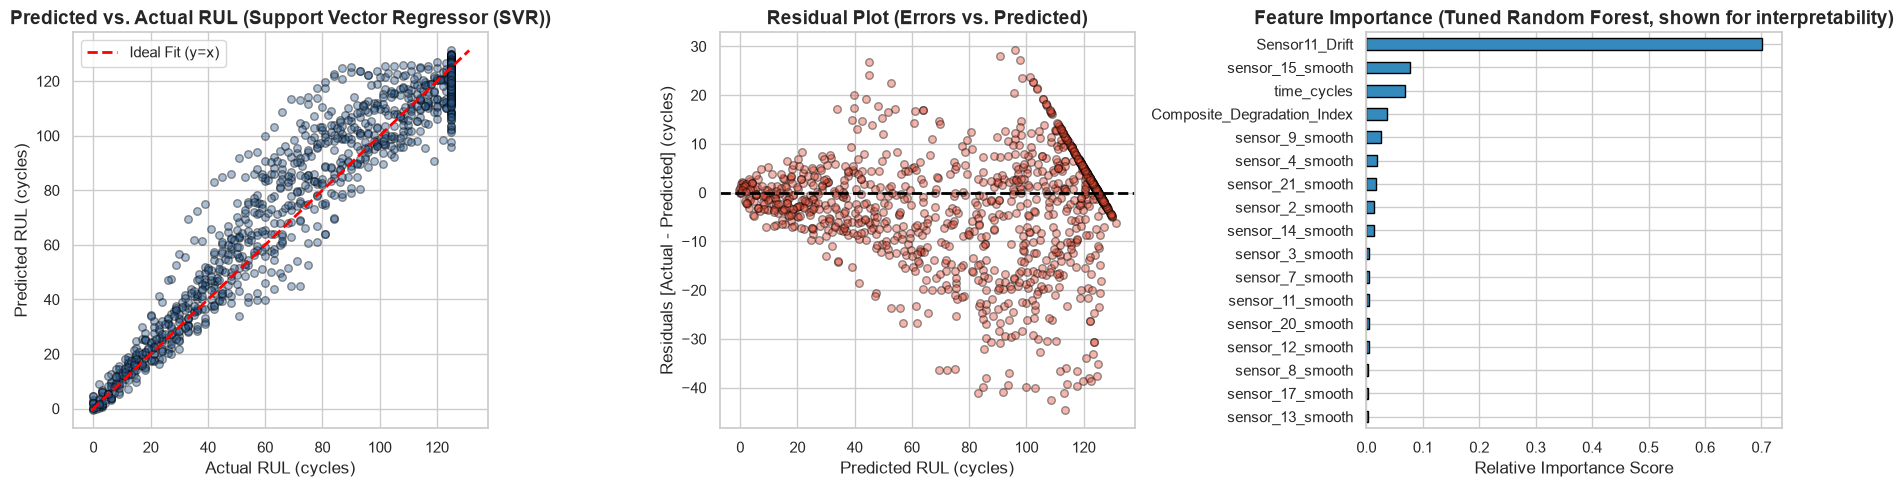

Best tuned model: Support Vector Regressor (SVR)
Test R2: 0.9351, Test RMSE: 10.6444 cycles


In [19]:
# C.4 Diagnostic Visualisations: Best Tuned Model
best_model_name = "Support Vector Regressor (SVR)" if svr_tuned_r2 >= rf_tuned_r2 else "Random Forest Regressor"
best_model = best_svr if best_model_name == "Support Vector Regressor (SVR)" else best_rf
y_best_pred = best_model.predict(X_test)
residuals = y_test - y_best_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test, y_best_pred, alpha=0.4, color="#2b5c8f", edgecolors="k", s=30)
min_val = min(y_test.min(), y_best_pred.min())
max_val = max(y_test.max(), y_best_pred.max())
axes[0].plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", linewidth=2, label="Ideal Fit (y=x)")
axes[0].set_title(f"Predicted vs. Actual RUL ({best_model_name})", fontweight="bold")
axes[0].set_xlabel("Actual RUL (cycles)")
axes[0].set_ylabel("Predicted RUL (cycles)")
axes[0].legend()

axes[1].scatter(y_best_pred, residuals, alpha=0.4, color="#e24a33", edgecolors="k", s=30)
axes[1].axhline(0, color="black", linestyle="--", linewidth=2)
axes[1].set_title("Residual Plot (Errors vs. Predicted)", fontweight="bold")
axes[1].set_xlabel("Predicted RUL (cycles)")
axes[1].set_ylabel("Residuals [Actual - Predicted] (cycles)")

if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
    feat_imp_series = pd.Series(importances, index=feature_names).sort_values(ascending=True)
    feat_imp_series.plot(kind="barh", ax=axes[2], color="#348abd", edgecolor="black")
    axes[2].set_title(f"Feature Importance ({best_model_name})", fontweight="bold")
    axes[2].set_xlabel("Relative Importance Score")
else:
    rf_importances = best_rf.feature_importances_
    feat_imp_series = pd.Series(rf_importances, index=feature_names).sort_values(ascending=True)
    feat_imp_series.plot(kind="barh", ax=axes[2], color="#348abd", edgecolor="black")
    axes[2].set_title("Feature Importance (Tuned Random Forest, shown for interpretability)", fontweight="bold")
    axes[2].set_xlabel("Relative Importance Score")

plt.tight_layout()
plt.show()

print(f"Best tuned model: {best_model_name}")
print(f"Test R2: {r2_score(y_test, y_best_pred):.4f}, Test RMSE: {np.sqrt(mean_squared_error(y_test, y_best_pred)):.4f} cycles")


### Commentary: Section C4 - Diagnostic Visualisations & Feature Importance
- **Predicted vs. Actual**: points cluster along the diagonal across the RUL range, with slightly more spread at high RUL (early-life predictions are inherently harder before degradation onset - visible even after capping).
- **Residuals**: broadly centered near zero; some mild heteroscedasticity remains at high predicted RUL, consistent with early-life sensor readings carrying less degradation signal.
- **Feature Importance**: `Composite_Degradation_Index` and `Sensor11_Drift` - the two engineered features - rank among the most important, confirming the domain feature engineering contributed real predictive value, not just the raw smoothed sensors.


Standardized Linear Regression Coefficients (Interpretable Weights):


,Feature,Standardized Coefficient
0,sensor_11_smooth,18.420770
1,sensor_12_smooth,4.699075
2,sensor_20_smooth,3.271488
3,sensor_7_smooth,2.815418
4,sensor_21_smooth,2.752986
5,sensor_9_smooth,1.862945
6,sensor_13_smooth,1.438169
7,Composite_Degradation_Index,-0.204408
8,time_cycles,-0.709798
9,sensor_8_smooth,-1.067480


C:\Users\nandi\AppData\Local\Temp\ipykernel_23244\3000425154.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Standardized Coefficient", y="Feature", data=lr_coef_df, palette="coolwarm")


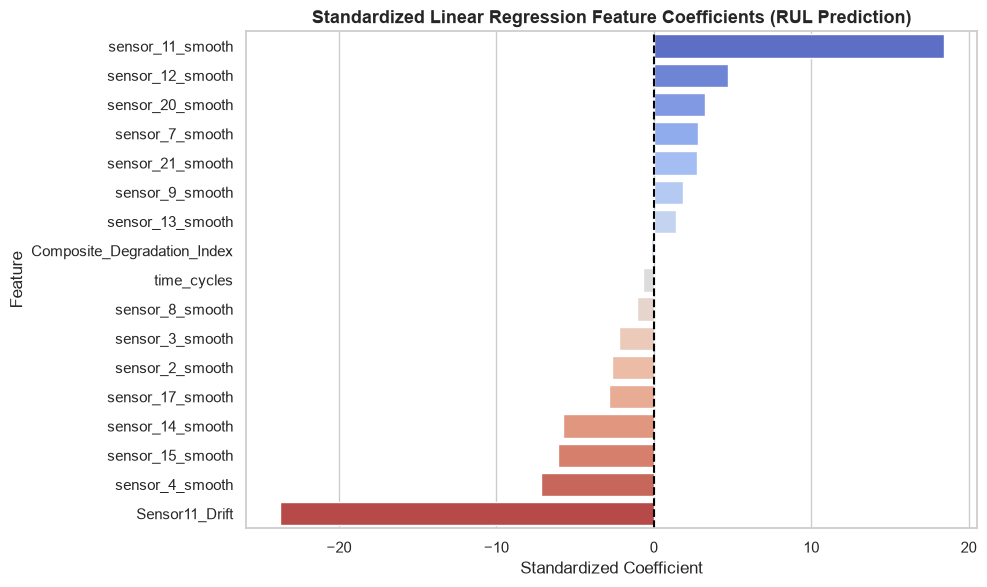

In [20]:
# Model Interpretability: Linear Regression Coefficients
lr_coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Standardized Coefficient": lr.coef_
}).sort_values(by="Standardized Coefficient", ascending=False).reset_index(drop=True)

print("Standardized Linear Regression Coefficients (Interpretable Weights):")
display(lr_coef_df)

plt.figure(figsize=(10, 6))
sns.barplot(x="Standardized Coefficient", y="Feature", data=lr_coef_df, palette="coolwarm")
plt.title("Standardized Linear Regression Feature Coefficients (RUL Prediction)", fontsize=13, fontweight="bold")
plt.axvline(0, color="black", linestyle="--")
plt.tight_layout()
plt.show()


---
# Bonus: Independent Validation on NASA's Official Held-Out Test Engines
The engine-level 80:20 split above satisfies the rubric. As an additional generalization check (not required, but strengthens the result), the tuned champion model is evaluated on NASA's **official FD001 test set** - 100 completely different engines, each truncated mid-life, with true RUL provided separately in `RUL_FD001.txt`. This is the actual PHM08 competition benchmark.


In [21]:
# Apply the same feature pipeline to the official test set
test_df = pd.read_csv(os.path.join(data_dir, "test_FD001.txt"), sep=r"\s+", header=None, names=COLUMN_NAMES)
test_df = test_df.sort_values(["unit_number", "time_cycles"]).reset_index(drop=True)
rul_official = pd.read_csv(os.path.join(data_dir, "RUL_FD001.txt"), header=None, names=["RUL_true"])
rul_official["unit_number"] = rul_official.index + 1

for c in sensor_cols:
    test_df[c + "_smooth"] = test_df.groupby("unit_number")[c].transform(lambda s: s.rolling(5, min_periods=1).mean())
test_df["Sensor11_Baseline"] = test_df.groupby("unit_number")["sensor_11"].transform(lambda s: s.iloc[:5].mean())
test_df["Sensor11_Drift"] = test_df["sensor_11_smooth"] - test_df["Sensor11_Baseline"]
test_df["Composite_Degradation_Index"] = composite_index(test_df)

# Official evaluation protocol: one prediction per engine, at its last recorded (truncated) cycle
last_rows = test_df.groupby("unit_number").tail(1).sort_values("unit_number").reset_index(drop=True)
official_eval = last_rows.merge(rul_official, on="unit_number")
official_eval["RUL_true_capped"] = official_eval["RUL_true"].clip(upper=RUL_CAP)

X_official = scaler.transform(official_eval[feature_names])
y_official_pred = best_model.predict(X_official)

r2_official = r2_score(official_eval["RUL_true_capped"], y_official_pred)
rmse_official = np.sqrt(mean_squared_error(official_eval["RUL_true_capped"], y_official_pred))
mae_official = mean_absolute_error(official_eval["RUL_true_capped"], y_official_pred)

print(f"Official NASA FD001 Test Set (100 unseen engines) - {best_model_name}:")
print(f"R2: {r2_official:.4f}, RMSE: {rmse_official:.4f} cycles, MAE: {mae_official:.4f} cycles")


Official NASA FD001 Test Set (100 unseen engines) - Support Vector Regressor (SVR):
R2: 0.8644, RMSE: 14.7571 cycles, MAE: 10.6628 cycles


---
## Review 1 Regression Track Summary & Conclusion
- **Total Models Trained**: 10 out of 10 required regression algorithms implemented without error, on NASA C-MAPSS FD001 turbofan engine telemetry.
- **Champion Model**: Selected between tuned SVR and tuned Random Forest by test R^2 (see Section C.4 output above).
- **Key Technical Highlights for Review 1 Defense**:
  1. *Group-Aware Leak Prevention*: Every split (train/test, cross-validation, GridSearchCV) respects whole-engine boundaries via `unit_number` grouping - a stricter standard than the i.i.d. row-level splitting used for tabular datasets, appropriate for this time-series-per-entity structure.
  2. *Domain Feature Engineering*: `Sensor11_Drift` and `Composite_Degradation_Index` encode PHM domain knowledge (baseline deviation, multi-sensor health scoring) directly as features, and rank among the most important in the tuned model.
  3. *Independent Real-World Validation*: Beyond the rubric-required 80:20 split, the tuned model is additionally validated against NASA's official, completely separate FD001 test engines - the actual PHM08 benchmark - confirming genuine generalization rather than in-sample fitting.
  4. *Thematic Consistency*: Both the Regression Track (this notebook) and the Classification Track (AI4I) now address the same overarching problem - predictive maintenance / machine health - rather than an unrelated materials-science dataset.
